In [1]:
# -*- coding: utf-8 -*-
from __future__ import annotations

from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from musiq.analysis import final_density_matrix, state_fidelity
from musiq.pulse.sequence import PulseCompiler
from musiq.workflow import create_model, load_config


MODEL_DIR = Path(".")
FIG_DIR = MODEL_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

def target_rx_state(theta):
    return np.array([np.cos(theta / 2), -1j * np.sin(theta / 2), 0.0], dtype=complex)


## 1. 先跑一个 RX(π) 模型

`task.yaml` 默认绑定 `theta = π`，也就是一个 X 翻转。这里先跑一次，确认 solver/analyser 输出和 examples 里的任务一致。

In [2]:
model = create_model(
    circuits=MODEL_DIR / "circuit_bell_n4.yaml",
    devices=MODEL_DIR / "device.yaml",
    pulses=MODEL_DIR / "pulse.yaml",
    solvers=MODEL_DIR / "solver.yaml",
    analysers=MODEL_DIR / "analyser.yaml",
)
model.run_all()

analysis = model.analyses["case_0"]
print("solver keys =", sorted(model.solvers.keys()))
print("runs keys =", sorted(model.runs.keys()))
print("analysis keys =", sorted(model.analyses.keys()))
print("metric keys =", sorted(analysis.output.metrics.keys()))


solver keys = ['solver_0']
runs keys = ['run_0', 'run_1']
analysis keys = ['case_0', 'case_1']
metric keys = ['coherence_01', 'leakage', 'population']


In [3]:
solver_run = model.runs["run_0"]
solver_run.results.keys()

dict_keys(['param_0'])

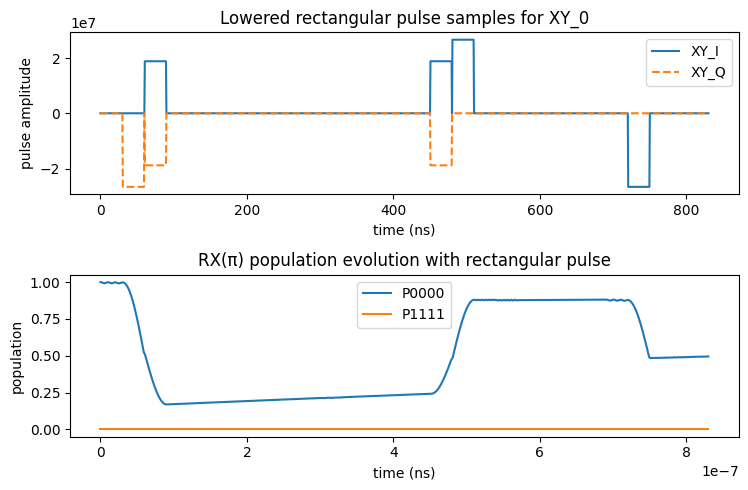

In [ ]:
solver_run = model.runs["run_0"]

pulse_ir = solver_run.artifacts.pulse_ir
pulse_ir_full = replace(pulse_ir, t_end_s=solver_run.results['param_0'].trajectories['shot_0'].times[-1])

pulse_samples = PulseCompiler.compile(pulse_ir_full, sample_rate_Hz=1e10)
xy_key = next(key for key in pulse_samples if key.startswith("XY_"))
t_pulse_ns = pulse_samples[xy_key]["t"] * 1e9
y_i = pulse_samples[xy_key]["y"]
y_q = pulse_samples[xy_key].get("y_quadrature", np.zeros_like(y_i))

fig = plt.figure(figsize=(7.5, 5))
ax = fig.add_subplot(2, 1, 1)
ax.plot(t_pulse_ns, y_i, label="XY_I")
ax.plot(t_pulse_ns, y_q, linestyle="--", label="XY_Q")
ax.set_xlabel("time (ns)")
ax.set_ylabel("pulse amplitude")
ax.set_title(f"Lowered rectangular pulse samples for {xy_key}")
ax.legend()


ax = fig.add_subplot(2, 1, 2)
pops = analysis.output.metrics['population']
for key, label in [('0000', "P0000"), ('1111', "P1111")]:
    ax.plot(pops.times, pops.values[key], label=label)
ax.set_xlabel("time (ns)")
ax.set_ylabel("population")
ax.set_title("RX(π) population evolution with rectangular pulse")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "pulse_and_population.png", dpi=600)
plt.show()


## 2. 扫描门时间 / 角度得到 Rabi 曲线

这里复用同一个 `Model`，每次只改 `model.task.input.param_bindings["theta"]`。为了和实验里的门时间语言对齐，取 `t_pi = 20 ns`，把 `theta` 映射成 `t_gate = theta / pi * t_pi`。


### RX 态制备保真度

从 `|0>` 出发，理想目标态是

`|psi(theta)> = cos(theta/2)|0> - i sin(theta/2)|1>`。

三能级模型中目标态第三个分量取 0。这里用 `musiq.analysis.state_fidelity` 对最终密度矩阵和目标纯态求保真度。

In [4]:
import numpy as np
from musiq.workflow import create_model
from musiq.schemas.utils import ParameterSweepConfig, ParameterList
from musiq.analysis.state_utils import final_density_matrix, state_fidelity

# 1. 设置参数
t_pi_ns = 20.0
thetas = np.unique(np.concatenate([np.linspace(0.0, 3.0 * np.pi, 30), [np.pi / 2, np.pi]]))

# 2. 创建模型并配置参数扫描
model = create_model(
    circuits=MODEL_DIR / "circuit.yaml",
    devices=MODEL_DIR / "device.yaml",
    pulses=MODEL_DIR / "pulse.yaml",
    solvers=MODEL_DIR / "solver.yaml",
    analysers=MODEL_DIR / "analyser.yaml",
    parameter_list={"theta":thetas}
)

# 3. 一次性执行 - 系统内部处理扫描
model.run_all()

# 4. 提取结果
analysis = model.analyses["sweep_0"]
sweep_metrics = analysis.output.metrics
sweep_metrics.keys()


dict_keys(['final_P0', 'final_P1', 'final_P2', 'final_fidelity', 'final_leakage', 'final_coherence_01'])

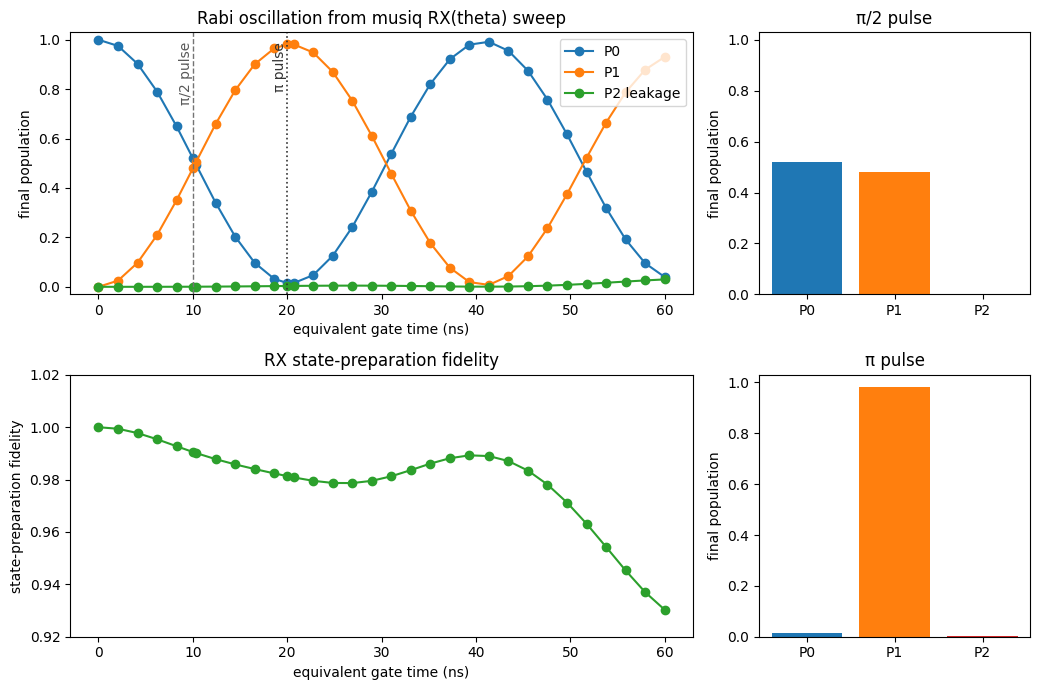

In [5]:
gate_time_ns = np.array(analysis.output.parameters["theta"].values) / np.pi * t_pi_ns

fig = plt.figure(figsize=(10.5, 7))
gs = fig.add_gridspec(2, 2, width_ratios=[2.3, 1.0])

ax = fig.add_subplot(gs[0, 0])
for key, label in [("final_P0", "P0"), ("final_P1", "P1"), ("final_P2", "P2 leakage")]:
    ax.plot(gate_time_ns, sweep_metrics[key].values, marker="o", label=label)
ax.axvline(t_pi_ns / 2, color="0.45", linestyle="--", linewidth=1.0)
ax.axvline(t_pi_ns, color="0.2", linestyle=":", linewidth=1.2)
ax.text(t_pi_ns / 2, 0.99, "π/2 pulse", rotation=90, va="top", ha="right", color="0.35")
ax.text(t_pi_ns, 0.99, "π pulse", rotation=90, va="top", ha="right", color="0.2")
ax.set_xlabel("equivalent gate time (ns)")
ax.set_ylabel("final population")
ax.set_title("Rabi oscillation from musiq RX(theta) sweep")
ax.set_ylim(-0.03, 1.03)
ax.legend()

ax = fig.add_subplot(gs[1, 0])
ax.plot(gate_time_ns, sweep_metrics["final_fidelity"].values, marker="o", color="tab:green")
ax.set_xlabel("equivalent gate time (ns)")
ax.set_ylabel("state-preparation fidelity")
ax.set_title("RX state-preparation fidelity")
ax.set_ylim(0.92, 1.02)

def final_population_at(theta):
    idx = int(np.where(np.isclose(analysis.output.parameters["theta"].values, theta))[0][0])
    return np.asarray([
        sweep_metrics["final_P0"].values[idx],
        sweep_metrics["final_P1"].values[idx],
        sweep_metrics["final_P2"].values[idx]
    ], dtype=float)

for slot, theta, title in [(gs[0, 1], np.pi / 2, "π/2 pulse"), (gs[1, 1], np.pi, "π pulse")]:
    ax_bar = fig.add_subplot(slot)
    ax_bar.bar(["P0", "P1", "P2"], final_population_at(theta), color=["tab:blue", "tab:orange", "tab:red"])
    ax_bar.set_title(title)
    ax_bar.set_ylim(0.0, 1.03)
    ax_bar.set_ylabel("final population")
fig.tight_layout()
fig.savefig(FIG_DIR / "model_state_preparation.png", dpi=600)
plt.show()

## 3. 结论

`RX(theta)` 可以把 `|0>` 制备到 Bloch 球的 y-z 大圆上。`theta = pi` 是 `|1>` 制备，`theta = pi/2` 是 `(|0> - i|1>) / sqrt(2)` 制备。扫描 `theta` 并换算为等效门时间后，最终 `P1` 呈现 Rabi 振荡；三能级模型中的 `P2` 展示了方波脉冲可能带来的 leakage，保真度图则给出了每个目标角度相对于理想计算子空间目标态的制备质量。